# ❖ Régression Logistique


- C’est le cas d'une entreprise qui détient un data set qui contient des informations sur des
clients qui ont acheté ou non des voitures après avoir reçu une publicité sur les réseaux
sociaux. Nous devons construire un modèle qui nous aide à prédire les acheteurs potentiels
pour leur envoyer des publicités ciblées.


Q1:

In [22]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from scipy.stats import uniform

Q2:

In [23]:
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())
print(df.info())
print(df["Purchased"].unique())# pour affiche les valeure de la colonne purchased .unique() affiche les valeurs uniques de la colonne "Purchased", dans ce ca son 0 et 1 

    User ID  Gender   Age  EstimatedSalary  Purchased
0  15624510    Male  19.0          19000.0          0
1  15810944    Male  35.0          20000.0          0
2  15668575  Female  26.0          43000.0          0
3  15603246  Female  27.0          57000.0          0
4  15804002    Male  19.0          76000.0          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB
None
[0 1]


Q3:

In [24]:
print(df.groupby("Gender")["Purchased"].value_counts())## pour affiche le nombre de personne qui ont acheter ou pas en fonction de leur genre

Gender  Purchased
Female  0            127
        1             77
Male    0            130
        1             66
Name: count, dtype: int64


Q4:

In [48]:
X = df.iloc[:, 1:-1].values  # Age et EstimatedSalary
y = df.iloc[:, 4].values    # Purchased
print(X[:5])
print("Shape X:", X.shape)
print("Shape y:", y.shape)
#calcule les valeure manqent 
df.isnull().sum()

[[1.0e+00 1.9e+01 1.9e+04]
 [1.0e+00 3.5e+01 2.0e+04]
 [0.0e+00 2.6e+01 4.3e+04]
 [0.0e+00 2.7e+01 5.7e+04]
 [1.0e+00 1.9e+01 7.6e+04]]
Shape X: (400, 3)
Shape y: (400,)


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Q5:

In [47]:
label = LabelEncoder()# pour convertir les valeurs de la colonne
df["Gender"] = label.fit_transform(df["Gender"])  # Male=1, Female=0



X = df[["Gender","Age","EstimatedSalary"]].values# pour selectionner les colonnes Gender
y = df["Purchased"].values
print(X[:5])

[[1.0e+00 1.9e+01 1.9e+04]
 [1.0e+00 3.5e+01 2.0e+04]
 [0.0e+00 2.6e+01 4.3e+04]
 [0.0e+00 2.7e+01 5.7e+04]
 [1.0e+00 1.9e+01 7.6e+04]]


Q6

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

Q7

In [30]:
scaler = StandardScaler() # pour normaliser les données, c'est important pour les algorithmes de machine learning qui sont sensibles à l'échelle des données, comme la régression logistique.
#z=(x-mean)/std pour normaliser les données, on soustrait la moyenne et on divise par l'écart type, ce qui permet d'avoir des données centrées autour de 0 et avec une échelle similaire.
X_train = scaler.fit_transform(X_train) # fit_transform() est utilisé pour ajuster le scaler aux données d'entraînement et les transformer en même temps. Cela garantit que les statistiques de normalisation (moyenne et écart type) sont calculées uniquement à partir des données d'entraînement, ce qui évite les fuites de données.
X_test = scaler.transform(X_test)# transform() est utilisé pour transformer les données de test en utilisant les mêmes statistiques de normalisation calculées à partir des données d'entraînement. 
#Cela garantit que les données de test sont normalisées de la même manière que les données d'entraînement, ce qui est crucial pour obtenir des performances cohérentes du modèle sur les deux ensembles de données.

Q8

In [31]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Q9:

In [34]:
y_pred = model.predict(X_test)
print(X_test[:10])
print (y_pred[:10])

[[ 1.02532046 -0.79895082  0.49460758]
 [-0.97530483 -0.02126485 -0.57735906]
 [ 1.02532046 -0.31289709  0.14694273]
 [-0.97530483 -0.79895082  0.26283101]
 [-0.97530483 -0.31289709 -0.57735906]
 [ 1.02532046 -1.09058306 -1.44652121]
 [-0.97530483 -0.70174008 -1.59138156]
 [ 1.02532046 -0.21568634  2.14601566]
 [-0.97530483 -1.96547978 -0.05586178]
 [ 1.02532046  0.85363187 -0.78016356]]
[0 0 0 0 0 0 0 1 0 1]


Q10:

[[56  2]
 [ 5 17]]


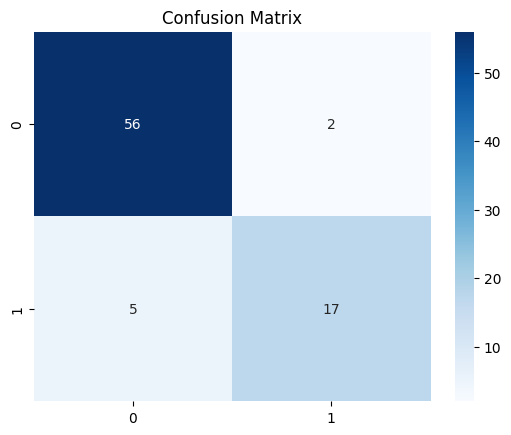

In [43]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.show()

Q11:

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
# accuracy_score() = ( TP + TN ) / ( TP + TN + FP + FN )
print("Precision :", precision_score(y_test, y_pred))
# precision_score() = TP / ( TP + FP ) 
print("Recall :", recall_score(y_test, y_pred))
# recall_score() = TP / ( TP + FN )
print("F1 Score :", f1_score(y_test, y_pred))
# F1 Score = 2 * ( Precision * Recall ) / ( Precision + Recall ) , 
# #c'est la moyenne harmonique de la précision et du rappel, elle est utilisée pour évaluer les modèles de classification,
# # en particulier lorsque les classes sont déséquilibrées.

Accuracy : 0.9125
Precision : 0.8947368421052632
Recall : 0.7727272727272727
F1 Score : 0.8292682926829268


Q12:

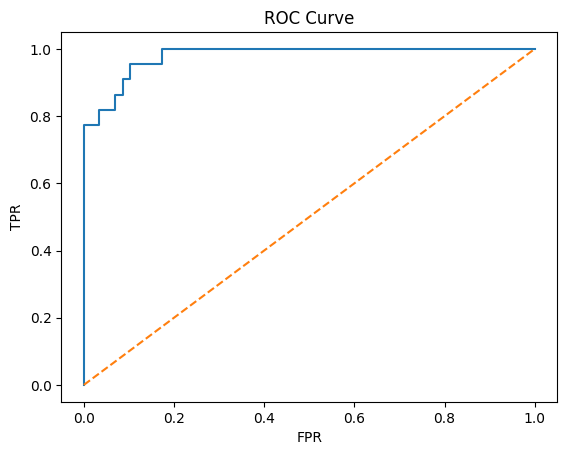

AUC = 0.9788401253918495


In [38]:
y_prob = model.predict_proba(X_test)[:,1] # predict_proba() retourne les probabilités de chaque classe pour chaque échantillon, et [:,1] sélectionne la probabilité de la classe positive (1) pour chaque échantillon.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)# roc_curve() calcule les taux de faux positifs (FPR), de vrais positifs (TPR) et les seuils correspondants pour différentes valeurs de seuil de classification. Ces valeurs sont utilisées pour tracer la courbe ROC, qui évalue la performance d'un modèle de classification en fonction de différents seuils.
roc_auc = auc(fpr, tpr)# auc() calcule l'aire sous la courbe ROC (AUC), qui est une mesure de la performance globale du modèle de classification. L'AUC varie entre 0 et 1, où une valeur de 1 indique une performance parfaite et une valeur de 0.5 indique une performance équivalente à un classificateur aléatoire.

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

print("AUC =", roc_auc)

Q13:

In [ ]:
scores = cross_val_score(model, X_train, y_train, cv=5) # cross_val_score() effectue une validation croisée en divisant les données d'entraînement en 5 plis (cv=5), entraînant le modèle sur 4 plis et le testant sur le pli restant à chaque itération. Les scores de précision pour chaque pli sont retournés dans un tableau.
print("CV Accuracy :", scores.mean())# scores.mean() calcule la moyenne des scores de précision obtenus à partir de la validation croisée, fournissant une estimation plus robuste de la performance du modèle sur les données d'entraînement.
# R^2 score en lignerregretion

CV Accuracy : 0.828125


Q14:

In [40]:
params = {
    "C": [0.1, 0.5, 1, 2, 3, 5],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(LogisticRegression(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Score: 0.828125


c:\Users\ilyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ilyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ilyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Q15:

In [41]:
best_model = grid.best_estimator_
y_pred2 = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision :", precision_score(y_test, y_pred2))
print("Recall :", recall_score(y_test, y_pred2))
print("F1 Score :", f1_score(y_test, y_pred2))

Accuracy : 0.9125
Precision : 0.8947368421052632
Recall : 0.7727272727272727
F1 Score : 0.8292682926829268


Q16:

In [21]:
C = uniform(loc=0, scale=4)
parameters_2 = {"C": C}

cv_random = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=parameters_2,
    n_iter=10,
    cv=5,
    random_state=0
)
cv_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'C': <scipy.stats....002674CD55D30>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: in

Q16:

In [22]:
print(cv_random.best_params_)
print(cv_random.best_score_)

{'C': np.float64(2.860757465489678)}
0.8299999999999998


Q18:

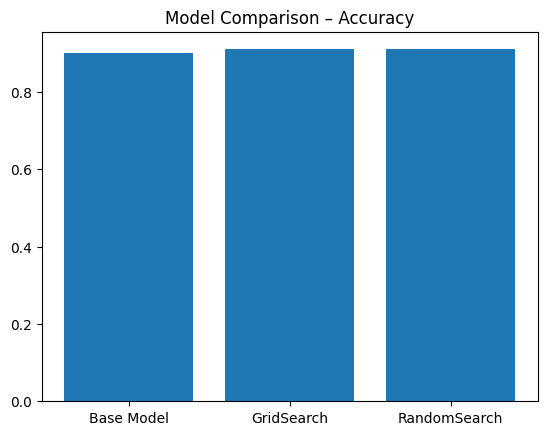

In [23]:
models = ["Base Model", "GridSearch", "RandomSearch"]
scores_plot = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred2),
    accuracy_score(y_test, cv_random.best_estimator_.predict(X_test))
]

plt.bar(models, scores_plot)
plt.title("Model Comparison – Accuracy")
plt.show()

Q19:

In [24]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-0.96104721]
Coefficients: [[0.09405663 2.09555319 1.11755905]]


# ❖ Comparaison des modèles

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

results = {}

for name, clf in models.items():
    # entraînement
    clf.fit(X_train, y_train)
    
    # prédictions
    y_pred = clf.predict(X_test)
    
    # calcul des métriques
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

# affichage des résultats
for model, metrics in results.items():
    print(f"\n📌 {model}")
    for metric, value in metrics.items():
        print(f"{metric} : {value:.4f}")


📌 KNN
Accuracy : 0.9500
Precision : 0.9527
Recall : 0.9500
F1 Score : 0.9506

📌 Decision Tree
Accuracy : 0.9000
Precision : 0.9097
Recall : 0.9000
F1 Score : 0.9024

📌 Random Forest
Accuracy : 0.9375
Precision : 0.9428
Recall : 0.9375
F1 Score : 0.9387

📌 Naive Bayes
Accuracy : 0.9250
Precision : 0.9242
Recall : 0.9250
F1 Score : 0.9238

📌 SVM
Accuracy : 0.9500
Precision : 0.9527
Recall : 0.9500
F1 Score : 0.9506
